In [1]:
import h5py
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cell_data import calculate_purity,cluster_matrix_hierarchical
import behave_ana
from scipy.stats import zscore,entropy
import matplotlib.gridspec as gridspec
from scipy.stats import sem  # 标准误差
from scipy.cluster.hierarchy import dendrogram,fcluster
from scipy.ndimage import uniform_filter1d
try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
from pathlib import Path
pkl_dir = '/home/zyyk78/HDD/zyyk78/Stage4/D06'
h5_root_dir = '/home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D06'
beh_video_dir = '/home/zyyk78/HDD/zyyk78/Stage4/video/CamT'

# ========== 构建日期到pkl的映射 ==========
pkl_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    date_key = pkl_file.name[:8]
    pkl_dict[date_key] = str(pkl_file)

# ========== 匹配 pkl 和 hdf ==========
hdf_dict = {}
for h5_file in Path(h5_root_dir).rglob("*.hdf5"):
    folder_date = h5_file.relative_to(h5_root_dir).parts[0].replace("_", "")
    if folder_date in pkl_dict:
        hdf_dict[folder_date] = str(h5_file)

# ========== 匹配 pkl 和 csv ==========
csv_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    evt_file = pkl_file.with_suffix('.evt')
    if not evt_file.exists():
        continue
    evt_mtime = evt_file.stat().st_mtime
    
    for mp4_file in Path(beh_video_dir).rglob("*.mp4"):
        if abs(mp4_file.stat().st_mtime - evt_mtime) < 10:  # 允许10秒误差
            csv_file = mp4_file.with_suffix('.csv')
            if csv_file.exists():
                csv_dict[pkl_file.name[:8]] = str(csv_file)
            break

# ========== 统一匹配结果 (pkl, hdf, csv) ==========
result_pairs = []
for date_key, pkl_path in pkl_dict.items():
    hdf_path = hdf_dict.get(date_key, None)
    csv_path = csv_dict.get(date_key, None)
    if hdf_path:  # 只保留同时有 pkl 和 hdf 的
        result_pairs.append((pkl_path, hdf_path, csv_path))

# 输出结果
for idx, (pkl_path, h5_path, csv_path) in enumerate(result_pairs):
    csv_str = csv_path if csv_path else "None"
    print(f'ID:{idx} PKL: {pkl_path} HDF5: {h5_path} CSV: {csv_str}')

ID:0 PKL: /home/zyyk78/HDD/zyyk78/Stage4/D06/20251223_T6F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D06/2025_12_23/14_38_41/miniscope1/0_20260104_174326_corr_20260122_170305_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-23_14-27-21_1.csv
ID:1 PKL: /home/zyyk78/HDD/zyyk78/Stage4/D06/20251212_T7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D06/2025_12_12/15_03_22/miniscope1/0_20260104_194733_corr_20260122_195324_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-12_14-51-54_1.csv
ID:2 PKL: /home/zyyk78/HDD/zyyk78/Stage4/D06/20251222_T6F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D06/2025_12_22/15_00_04/miniscope1/0_20260104_180516_corr_20260122_173318_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-22_14-52-27_1.csv
ID:3 PKL: /home/zyyk78/HDD/zyyk78/Stage4/D06/20251119_P7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/D06/2025_11_19/15_49_31/miniscope1/0_20260104_190229_corr

In [3]:
ID = 15
mode = 'C'
smooth_w = 0.5
pkl_path, hdf_path, csv_path = result_pairs[ID]

with h5py.File(hdf_path, 'r') as hdf_file:
    fr = hdf_file['params']['data']['fr'][()]
    C = np.array(hdf_file['estimates']['C'])
    C_z = zscore(C, axis=1)
    S = np.array(hdf_file['estimates']['S'])
    S_sm = uniform_filter1d(S, size = int(smooth_w*fr), axis=1)
    S_z = zscore(S_sm, axis=1)
    
with open(pkl_path,"rb") as pkl_f:
        Event=pickle.load(pkl_f)   

# 加载 CSV 文件并进行二次插值
csv_data = None
pos_frames = None
pos_centroids = None
pos_interp = None  # T*2 的位置坐标数组
pos_fps = None  # CSV 的帧率
if csv_path:
    # 读取前两行获取总时长和总帧数
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
        second_line = f.readline().strip()
    total_duration = float(first_line.split(':')[1].split()[0].strip())  # 秒
    total_frames = int(second_line.split(':')[1].strip())
    pos_fps = total_frames / total_duration
    
    print(f'CSV total duration: {total_duration} s')
    print(f'CSV total frames: {total_frames}')
    print(f'CSV fps: {pos_fps}')
    
    # 读取CSV数据（跳过前两行备注）
    csv_data = pd.read_csv(csv_path, skiprows=2)
    pos_frames = csv_data['frame'].values
    pos_centroids = csv_data[['centroid_x', 'centroid_y']].values
    
    # 去除 NaN 值
    valid_mask = ~np.isnan(pos_centroids).any(axis=1)
    pos_frames_clean = pos_frames[valid_mask]
    pos_centroids_clean = pos_centroids[valid_mask]
    print(f'Valid points: {len(pos_frames_clean)} / {len(pos_frames)}')
    
    # 二次插值到完整帧数
    from scipy.interpolate import interp1d
    
    # 对 x 和 y 分别进行二次插值
    interp_x = interp1d(pos_frames_clean, pos_centroids_clean[:, 0], kind='quadratic', 
                        bounds_error=False, fill_value='extrapolate')
    interp_y = interp1d(pos_frames_clean, pos_centroids_clean[:, 1], kind='quadratic', 
                        bounds_error=False, fill_value='extrapolate')
    
    all_frames = np.arange(total_frames)
    pos_interp = np.column_stack([interp_x(all_frames), interp_y(all_frames)])
    print(f'pos_interp shape: {pos_interp.shape}')
    print(f'NaN in pos_interp: {np.isnan(pos_interp).sum()}')
    print(f'Sample pos_interp[0]: {pos_interp[0]}')

if mode == 'S':
    signal = S_z
    print('钙信号模式')
elif mode == 'C':
    signal = C_z
    print('反卷积模式')

CSV total duration: 2544.46 s
CSV total frames: 75780
CSV fps: 29.782350675585388
Valid points: 6876 / 6889
pos_interp shape: (75780, 2)
NaN in pos_interp: 0
Sample pos_interp[0]: [444.67 159.51]
反卷积模式


In [4]:
from cell_data import match_segments
keep_list=['MinS','SlnL','SlnR','ROmL','ROmR','LickL','LickR']
ignore_list=[i for i in list(Event.keys()) if i not in keep_list]
long_event=['Blackhole','MinS']
eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
eve_list,signal=match_segments(eve_list,signal)

检测完成：共发现 2 段记录。

段落         | 开始时间            | 结束时间            | 持续帧数      
------------------------------------------------------------
Segment 1  | 41690178        | 41972138        | 140       
Segment 2  | 42796068        | 101656329       | 29006     
Len of MS Record:  29006
Dropped frams:  0
Most like seq is:  2


In [11]:
# ========== Place Field 计算 ==========
# 先计算 pos_segment
start_ts = eve_list[0][0]   # 起始时间戳
end_ts = eve_list[-1][0]    # 结束时间戳
start_time_sec = start_ts / 50000  # 转换为秒
end_time_sec = end_ts / 50000

print(f'Start timestamp: {start_ts} -> {start_time_sec:.2f} s')
print(f'End timestamp: {end_ts} -> {end_time_sec:.2f} s')
print(f'Duration: {end_time_sec - start_time_sec:.2f} s')
print(f'Signal frames: {signal.shape[1]}')

# 使用 pos 的 fps 计算对应的帧
if pos_interp is not None and pos_fps is not None:
    start_pos_frame = int(start_time_sec * pos_fps)
    end_pos_frame = int(end_time_sec * pos_fps)
    
    print(f'Pos fps: {pos_fps}')
    print(f'Start -> Pos frame: {start_pos_frame}')
    print(f'End -> Pos frame: {end_pos_frame}')
    
    # 截取对应区间的位置坐标
    pos_segment = pos_interp[start_pos_frame:end_pos_frame]
    print(f'Pos segment before resample: {pos_segment.shape}')
    
    # 插值到与 hdf (signal) 相同的帧数
    from scipy.interpolate import interp1d
    
    signal_frames = signal.shape[1]
    orig_frames = np.arange(len(pos_segment))
    target_frames = np.linspace(0, len(pos_segment) - 1, signal_frames)
    
    interp_x = interp1d(orig_frames, pos_segment[:, 0], kind='linear', 
                        bounds_error=False, fill_value='extrapolate')
    interp_y = interp1d(orig_frames, pos_segment[:, 1], kind='linear', 
                        bounds_error=False, fill_value='extrapolate')
    
    pos_segment = np.column_stack([interp_x(target_frames), interp_y(target_frames)])
    print(f'Pos segment resampled: {pos_segment.shape}')
else:
    print('No pos_interp or pos_fps available')


Start timestamp: 42796068 -> 855.92 s
End timestamp: 101656329 -> 2033.13 s
Duration: 1177.21 s
Signal frames: 29006
Pos fps: 29.782350675585388
Start -> Pos frame: 25491
End -> Pos frame: 60551
Pos segment before resample: (35060, 2)
Pos segment resampled: (29006, 2)


Computed place fields for 47 neurons
Sample scores for first 5 neurons:
  Neuron 0: SI=1.450, Sparsity=0.806, Coherence=0.271, Score=1.021
  Neuron 1: SI=0.191, Sparsity=0.325, Coherence=0.353, Score=0.264
  Neuron 2: SI=0.166, Sparsity=0.137, Coherence=0.372, Score=0.198
  Neuron 3: SI=0.568, Sparsity=0.616, Coherence=0.412, Score=0.551
  Neuron 4: SI=0.201, Sparsity=0.155, Coherence=0.336, Score=0.214


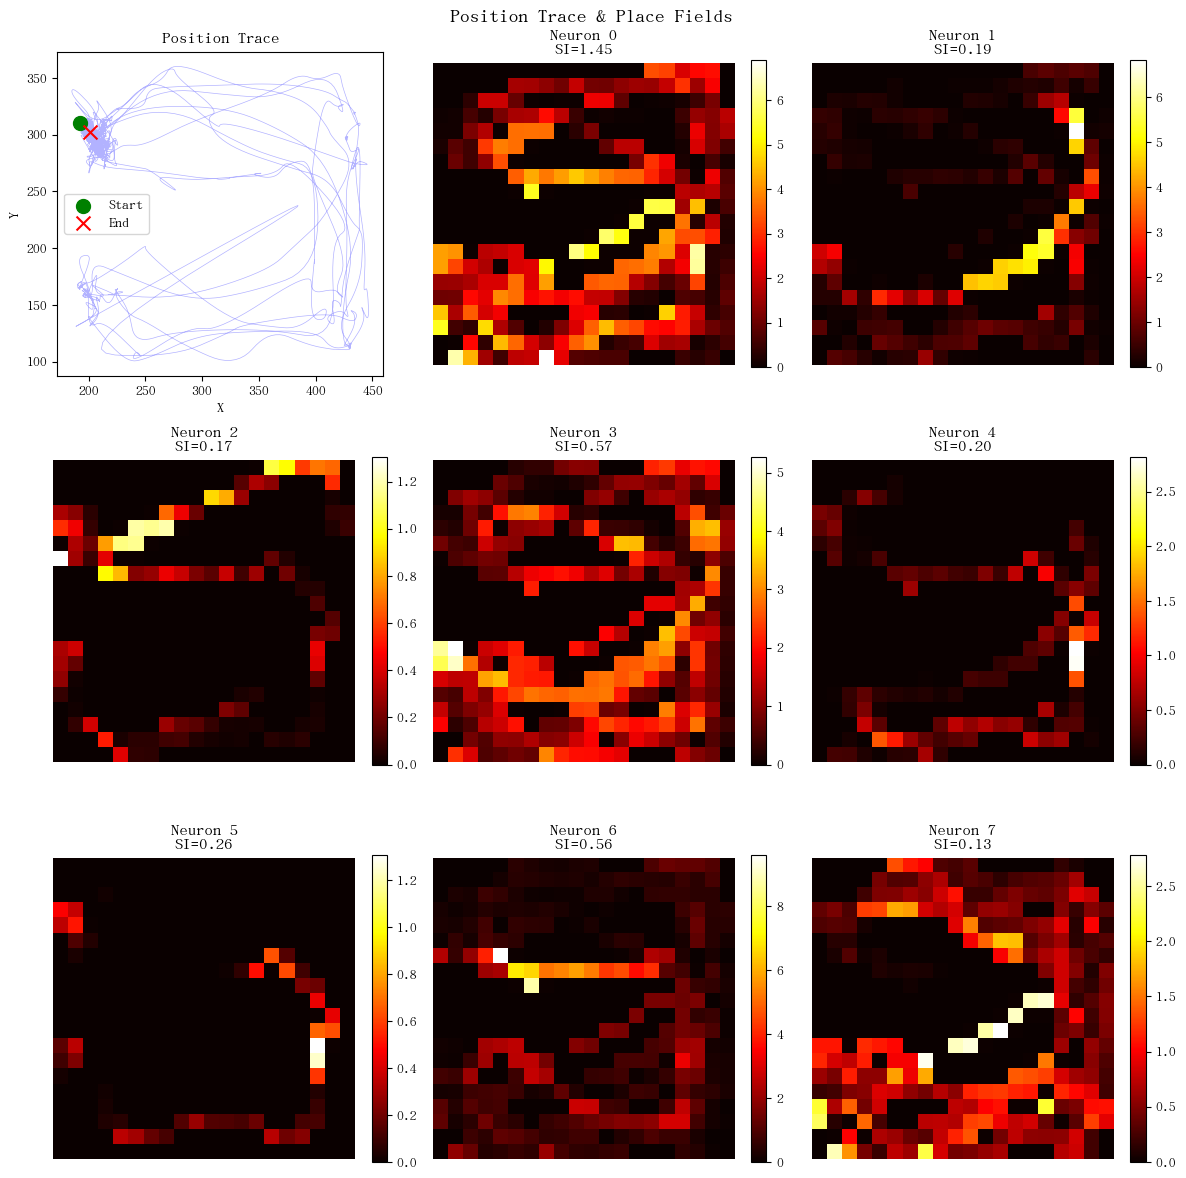

In [14]:
# 计算 Place Field
from cell_data import compute_place_fields

place_fields, place_scores = compute_place_fields(signal, pos_segment, chunknum=20, smooth_sigma=.3)

num_neurons = signal.shape[0]
print(f'Computed place fields for {num_neurons} neurons')
print(f'Sample scores for first 5 neurons:')
for i in range(min(5, num_neurons)):
    print(f'  Neuron {i}: SI={place_fields[i]["spatial_info"]:.3f}, '
          f'Sparsity={place_fields[i]["sparsity"]:.3f}, '
          f'Coherence={place_fields[i]["coherence"]:.3f}, '
          f'Score={place_scores[i]:.3f}')

# ========== Place Field 可视化 ==========
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# 1号位置画轨迹
ax_trace = axes[0]
ax_trace.plot(pos_segment[:, 0], pos_segment[:, 1], 'b-', alpha=0.3, linewidth=0.5)
ax_trace.scatter(pos_segment[0, 0], pos_segment[0, 1], c='green', s=100, marker='o', label='Start', zorder=5)
ax_trace.scatter(pos_segment[-1, 0], pos_segment[-1, 1], c='red', s=100, marker='x', label='End', zorder=5)
ax_trace.set_title('Position Trace')
ax_trace.legend()
ax_trace.set_xlabel('X')
ax_trace.set_ylabel('Y')
ax_trace.set_aspect('equal')

# 其余位置画 place field (2-9号)
for i in range(1, 9):
    ax = axes[i]
    neuron_id = i - 1  # 神经元索引（0开始）
    if neuron_id >= num_neurons:
        ax.axis('off')
        continue
        
    rate_map = place_fields[neuron_id]['rate_map']
    
    im = ax.imshow(rate_map, cmap='hot', origin='lower')
    ax.set_title(f'Neuron {neuron_id}\nSI={place_fields[neuron_id]["spatial_info"]:.2f}')
    ax.axis('off')
    
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Position Trace & Place Fields', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
trigger_Rew=[]
trigger_Rom=[]
trigger_TL=[]
trigger_TR=[]
trigger_All=[]
frame_count = 0
for _,eve in eve_list:
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue
    elif eve in ['SlnL','SlnR','ROmL','ROmR']:
        trigger_All.append(frame_count)
          
    if eve=='SlnL' or eve=='SlnR':
        trigger_Rew.append(frame_count)
    if eve=='ROmL' or eve =='ROmR':
        trigger_Rom.append(frame_count)   
    if eve=='SlnL' or eve == 'ROmL':
        trigger_TL.append(frame_count)
    if eve=='SlnR' or eve == 'ROmR':
        trigger_TR.append(frame_count)
    if not eve in keep_list:
        print('Error ',eve)
trigger_list_E=   [trigger_Rew,trigger_Rom,trigger_TL,trigger_TR,trigger_All]        

matrix_list_E=[]
matrix_pur_list_E=[]
matrix_E_list_E=[]
for trigger in trigger_list_E:
    react_list=[]
    for i in trigger:
        crop_data=np.array(signal[:,max(i - 50,0):min(i + 51,signal.shape[1])])   
        if crop_data.shape[1] == 101:
            react_list.append(crop_data)

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    En,purity = calculate_purity(react_list_stack)
    matrix_list_E.append(mean_responses)
    matrix_pur_list_E.append(purity)
    matrix_E_list_E.append(En)
    
#################################################    
trigger_Sw_S=[]
trigger_Sw_E=[]
frame_count=0
past_side=None
past_count=None
for _,eve in eve_list:
    
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue

    curr_side = 'L' if eve=='SlnL' or eve=='ROmL' else 'R' if eve=='SlnR' or eve == 'ROmR' else past_side
    if curr_side != past_side and past_side!=None and past_count!=None:
        trigger_Sw_E.append(frame_count)
        trigger_Sw_S.append(past_count)
    past_side = curr_side
    past_count = frame_count
    
trigger_list_S=   [trigger_Sw_S,trigger_Sw_E]        

matrix_list_S=[]
matrix_pur_list_S=[]
for trigger in trigger_list_S:
    react_list=[]
    for i in trigger:
        crop_data=np.array(signal[:,max(i - 125,0):min(i + 126,signal.shape[1])])
        if crop_data.shape[1] == 251:
            react_list.append(crop_data)

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    _,purity = calculate_purity(react_list_stack)
    matrix_list_S.append(mean_responses)
    matrix_pur_list_S.append(purity)
#################################################
matrix_list_E=np.array(matrix_list_E)
matrix_pur_list_E=np.array(matrix_pur_list_E)
matrix_E_list_E=np.array(matrix_E_list_E)

matrix_list_S=np.array(matrix_list_S)
matrix_pur_list_S=np.array(matrix_pur_list_S)

trigger_list=trigger_list_E+trigger_list_S

In [ ]:
n_clusters = 4
use_pur = False

mix_data=[]
if use_pur:
    for (mat,pur) in zip(matrix_list_E,matrix_pur_list_E):
        mix_data.append(mat*pur)
        
    for (mat,pur) in zip(matrix_list_S,matrix_pur_list_S):
        mix_data.append(mat*pur)
else:
    for mat in matrix_list_E:
        mix_data.append(mat)
        
    for mat in matrix_list_S:
        mix_data.append(mat)
    
tot_mix_data = np.concatenate(mix_data, axis=1)
features, sorted_idx,cluster,Z=cluster_matrix_hierarchical(tot_mix_data,max_features=20,n_clusters=n_clusters,metric='correlation',linkage_method='average')


titles = ["Reward", "Unreward", "Trial L", "Trial R", "Trial All","Switsh_S", "Switsh_E"]
lens=[2,2,2,2,2,5,5]
width_r=[1,1,1,1,1,2.5,2.5]

plt.rcParams.update({
    'font.size': 16,         # 所有字体的默认大小
    'axes.titlesize': 18,    # 子图标题大小
    'axes.labelsize': 16,    # 坐标轴标签字体
    'xtick.labelsize': 18,   # x 轴刻度字体
    'ytick.labelsize': 14,   # y 轴刻度字体
    'legend.fontsize': 14,   # 图例字体
    'figure.titlesize': 20   # 整体大标题字体
})



# ========== 构建 Figure ==========
fig = plt.figure(figsize=(25, 14), dpi=300)
gs = gridspec.GridSpec(2, 8, height_ratios=[2, 1], width_ratios=[1]+width_r, wspace=0.05, hspace=0.05)

# ========== 上方：dendrogram 和 heatmap ==========
last_merge_distances = sorted(Z[:, 2], reverse=True)  # 所有合并距离（降序）
cut_height = last_merge_distances[features[0] - 2]     # 直接取第n_clusters-1大的距离

ax_dendro = plt.subplot(gs[0, 0])
axes_heat = [plt.subplot(gs[0, i+1]) for i in range(7)]

dendro_data = dendrogram(
    Z,
    ax=ax_dendro,
    orientation='left',
    color_threshold=cut_height,
    no_labels=True
)
ax_dendro.axvline(x=cut_height, color='r', linestyle='--', linewidth=1.5,)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.set_title('Dendrogram')
# ========== 分配标签 ==========
labels = fcluster(Z, features[0], criterion='maxclust')  # 每个神经元所属簇
sorted_idx = dendro_data['leaves'][::-1]  # 已排序的神经元索引

from collections import defaultdict

cluster_colors = defaultdict(lambda: 'gray')
leaves = dendro_data['leaves']        # 序号排序
leaves_colors = dendro_data['leaves_color_list']  # 每个leaf的颜色

# 构建 cluster_id -> color 的映射
for idx, leaf in enumerate(leaves):
    cluster_id = cluster[leaf]
    if cluster_id not in cluster_colors:
        cluster_colors[cluster_id] = leaves_colors[idx]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_heat)):
    im = ax.imshow(matrix[sorted_idx], cmap='bwr', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.axvline(x=matrix.shape[1]//2, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_title(titles[i]+f'\nn_event={len(trigger_list[i])}')
    ax.set_xticks([])


# ========== 下方：每个簇的平均响应 ± SEM ==========
axes_avg = [plt.subplot(gs[1, i+1]) for i in range(7)]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_avg)):
    x = np.linspace(-lens[i], lens[i], matrix.shape[1])
    for cluster_id in range(1, features[0]+1):
        cluster_idx = np.where(labels == cluster_id)[0]
        mean_trace = matrix[cluster_idx].mean(axis=0)
        error = sem(matrix[cluster_idx], axis=0)

        ax.plot(x, mean_trace, label=f'Cluster {cluster_id}', color=cluster_colors[cluster_id])
        ax.fill_between(x, mean_trace-error, mean_trace+error, color=cluster_colors[cluster_id], alpha=0.3)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_xlabel(f'Time: ±{lens[i]} s')
    ax.set_xticks([(x[0]+x[-1])/2])
    ax.set_xticklabels([0])
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-0.5, 0.5)
    ax.axhline(y=0, color='red', linewidth=1)
axes_avg[0].set_yticks([-0.5,0,0.5])
plt.tight_layout(rect=[0, 0, 1, 1], pad=0.5)
cbar_ax = fig.add_axes([0.35, -0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean_Resp * Purity')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dPCA.dPCA as dpca_module

def run_dpca(eve_list, signal, fs=20):
    n_neurons = signal.shape[0]
    ms_frames = np.array([t for t, e in eve_list if e == 'MinS_S' or e == 'MinS_E'])
    
    # --- 1. 构建包含所有要素的 DataFrame ---
    trial_events = ['SlnL', 'SlnR', 'ROmL', 'ROmR']
    data = []
    for t, e in eve_list:
        if e in trial_events:
            f_idx = np.argmin(np.abs(ms_frames - t))
            data.append({
                'frame': f_idx,
                'c': 1 if 'R' in e else 0,
                'r': 1 if 'Sln' in e else 0
            })
    df = pd.DataFrame(data)
    
    # 历史要素
    df['p'] = df['c'].shift(1)
    df['pr'] = df['r'].shift(1)
    
    df['progress'] = (df.index > (len(df)/2)).astype(int) 
    
    df = df.dropna().reset_index(drop=True)

    n_time = 25
    conditions = [2, 2, 2, 2] # c, r, p, pr
    data_tensor = np.zeros((n_neurons, 2, 2, 2, 2, n_time))
    
    for c in [0,1]:
        for r in [0,1]:
            for p in [0,1]:
                for pr in [0,1]:
                    mask = (df['c']==c) & (df['r']==r) & (df['p']==p) & (df['pr']==pr)
                    subset = df[mask]
                    if len(subset) > 0:
                        signals = []
                        for f in subset['frame']:
                            if f-12 >= 0 and f+13 <= signal.shape[1]:
                                signals.append(signal[:, f-12:f+13])
                        if signals:
                            data_tensor[:, c, r, p, pr, :] = np.mean(signals, axis=0)

    # --- 3. 初始化并拟合 ---
    # labels 指定顺序：c, r, p, pr, time (t 是隐含的最后一位)
    dpca = dpca_module.dPCA(labels='crpht', regularizer=0.005) 
    data_tensor_mean = np.mean(data_tensor.reshape(n_neurons, -1), axis=1)
    data_tensor_centered = data_tensor - data_tensor_mean[:, None, None, None, None, None]
    Z = dpca.fit_transform(data_tensor_centered)
    
    return dpca, Z

# 使用示例:
dpca_model, results = run_dpca(eve_list, signal)

expl_var = dpca_model.explained_variance_ratio_
# 计算每个组合的总方差（求和所有分量）
labels = list(expl_var.keys())
values = [np.sum(expl_var[k]) for k in labels]

# 按方差大小排序，方便观察
sorted_idx = np.argsort(values)[::-1]
sorted_labels = [labels[i] for i in sorted_idx]
sorted_values = [values[i] for i in sorted_idx]

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_labels, sorted_values, color='teal', alpha=0.8)
plt.xticks(rotation=90)
# 在柱状图上方标注数值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, 
                f'{yval:.2%}', ha='center', va='bottom', fontsize=10)

plt.title('Variance Explained by All Factors and Interactions', fontsize=15)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Marginalization (Factors)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dpca_results_fixed(Z, dpca, fs=20):
    time_axis = np.arange(-12, 13) / fs # 长度 25
    
    # 你的 labels 是 'crpht'，对应的维度索引（除神经元外）是：
    # 0:curr_c, 1:curr_r, 2:prev_c, 3:prev_h, 4:time(t)
    
    components = ['c', 'r', 'p', 'h'] 
    comp_names = {
        'c': 'Current Choice (L vs R)',
        'r': 'Current Reward (Rew vs No)',
        'p': 'Previous Choice (L vs R)',
        'h': 'Previous Reward (Rew vs No)'
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, label in enumerate(components):
        ax = axes[i]
        
        # 1. 提取该成分的第1主成分数据
        # 形状应该是 (2, 2, 2, 2, 25)
        data = Z[label][0] 
        
        # 2. 确定该标签在 'crpht' 中的索引
        target_idx = 'crpht'.index(label)
        
        # 3. 计算两条线
        # 我们要保留 target_idx 这一维和 最后一维 (time)
        # 把剩下的 3 个维度全部平均掉
        all_dims = list(range(4)) # 不含时间维 4
        all_dims.remove(target_idx)
        axes_to_reduce = tuple(all_dims)
        
        # mean 之后，结果应该是 (2, 25)
        collapsed_data = np.mean(data, axis=axes_to_reduce)
        
        line_0 = collapsed_data[0, :] # 形状应该是 (25,)
        line_1 = collapsed_data[1, :] # 形状应该是 (25,)
        
        # 4. 绘图
        ax.plot(time_axis, line_0, 'b', label=f'{label}=0 (L/No)', linewidth=2.5)
        ax.plot(time_axis, line_1, 'r', label=f'{label}=1 (R/Yes)', linewidth=2.5)
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.5)
        ax.set_title(comp_names[label], fontsize=14, fontweight='bold')
        ax.set_xlabel('Time from lick (s)')
        ax.set_ylabel('dPC Score (a.u.)')
        ax.legend()
        ax.grid(True, alpha=0.2)

    plt.suptitle('Reinforcement Learning Factors: dPCA Demixed Components', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

# 调用
plot_dpca_results_fixed(results, dpca_model)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
n_components = 20
n_shown = 10

N, T = signal.shape
X = signal.T
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=n_components)
pca_results = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
print(f'前{n_components}个成分解释方差总占比: {explained_var[:n_components].sum():.1%}')
print(f"成分解释方差占比(PC0-PC{n_shown-1}): {explained_var[:n_shown]}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 使用时间序列 T 作为颜色映射 (colormap)
time_points = np.arange(T)
p = ax.scatter(pca_results[:, 0], pca_results[:, 1], pca_results[:, 2], 
               c=time_points, cmap='viridis', s=5)

# 标注起始点和终点
ax.scatter(pca_results[0, 0], pca_results[0, 1], pca_results[0, 2], c='red', s=100, label='Start')
ax.scatter(pca_results[-1, 0], pca_results[-1, 1], pca_results[-1, 2], c='black', s=100, label='End')

ax.set_xlabel(f'PC1 ({explained_var[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1%})')
ax.set_zlabel(f'PC3 ({explained_var[2]:.1%})')
ax.set_title('Neural Population Dynamics (PCA)')
fig.colorbar(p, label='Time Points')
plt.legend()
plt.show()


In [ ]:
feature_names = ['Trial', 'Reward', 'Switch', 'Lick', 'Count_Reward','Rec_Time','Position']
event_array = np.zeros((signal.shape[1],len(feature_names)))  #是否尝试,是否奖励,是否切换侧,lick行为,累计奖励,试验时间,相对位置

i = -1
count_reward = 0
curr_side = None
for ts,eve in eve_list:
    
    if eve == 'MinS_S' or eve=='MinS_E':
        i+=1
        event_array[i,:] = np.array([0,0,0,0,count_reward,ts,-1]) if curr_side=='L' else np.array([0,0,0,0,count_reward,ts,1])
    if eve == 'SlnL':
        count_reward += 1
        event_array[i] = np.array([1,1,0,0,count_reward,ts,-1])
        curr_side = 'L'
    if eve == 'SlnR':
        count_reward += 1
        event_array[i] = np.array([1,1,0,0,count_reward,ts,1])
        curr_side = 'R'
    if eve == 'ROmL':
        event_array[i] = np.array([1,0,0,0,count_reward,ts,-1])
        curr_side = 'L'
    if eve == 'ROmR':
        event_array[i] = np.array([1,0,0,0,count_reward,ts,1])
        curr_side = 'R'
    if eve == 'LickL' or eve == 'LickR':
        event_array[i,3] =1
        
attempt_indices = np.where(event_array[:, 0] == 1)[0]

for k in range(len(attempt_indices) - 1):
    idx_curr = attempt_indices[k]
    idx_next = attempt_indices[k+1]
    
    side_curr = event_array[idx_curr, -1] # 当前位置
    side_next = event_array[idx_next, -1] # 下一次位置

    if side_curr != side_next:
        event_array[idx_curr, 2] = -1
        event_array[idx_next, 2] = 1
        num_gap_points = idx_next - idx_curr -1
        if num_gap_points > 0:
            event_array[idx_curr+1 : idx_next, -1] = np.zeros(num_gap_points)
        
####施工中,待续未完,或许可以加入更多数据,比如行为摄像机解析到的位置信息(理论上来讲)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 建议先对特征进行标准化，这样回归系数 Beta 才能在同一量级比较贡献度
scaler = StandardScaler()
event_array_scaled = scaler.fit_transform(event_array)

# 准备存储系数的矩阵 (PC数量 x 特征数量)
num_pcs = n_shown
num_features = len(feature_names)
coef_matrix = np.zeros((num_pcs, num_features))
r2_list = []

for i in range(num_pcs):
    model = LinearRegression().fit(event_array_scaled, pca_results[:, i])
    # 存储回归系数的绝对值，代表贡献权重
    coef_matrix[i, :] = np.abs(model.coef_)
    # 存储该 PC 的总解释方差 R^2
    r2_list.append(model.score(event_array_scaled, pca_results[:, i]))

# 转化为 DataFrame 方便绘图
df_plot = pd.DataFrame(coef_matrix, 
                       index=[f'PC{i+1}' for i, _ in enumerate(r2_list)], 
                       columns=feature_names)

# 绘制热图
plt.figure(figsize=(10, 6))
sns.heatmap(df_plot, annot=False, cmap='rainbow' )
plt.title('Importance of Behavioral Features for each PC (Linear Regression Coeffs)')
plt.ylabel('Principal Components (with total R²)')
plt.xlabel('Behavioral Features')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print_mode = [1,1,2,1,0,0,0]  #1: 0-1模式 2: -1,0,1模式 0: 乱序不分层
num_features = len(feature_names)

fig, axes = plt.subplots(1, num_features, figsize=(5 * num_features, 5))

for i, (name, mode) in enumerate(zip(feature_names,print_mode)):
    ax = axes[i]
    data = event_array[:, i]
    
    if mode == 1:
        # 先画背景（值为0的点）
        mask_bg = (data == 0)
        ax.scatter(pca_results[mask_bg, 0], pca_results[mask_bg, 1], 
                   c='lightgray', s=1, alpha=0.1, label='None')
        
        # 再画前景（非0点，用醒目的红色）
        mask_fg = (data != 0)
        sc = ax.scatter(pca_results[mask_fg, 0], pca_results[mask_fg, 1], 
                        c='crimson', s=8, alpha=0.8, label=name)
        ax.legend(loc='upper right', markerscale=2)

    elif mode == 2:
        # 先画背景
        mask_0 = (data == 0)
        ax.scatter(pca_results[mask_0, 0], pca_results[mask_0, 1], 
                   c='lightgray', s=1, alpha=0.1)
        
        # 画小于0的点（例如离开侧，蓝色）
        mask_neg = (data < 0)
        ax.scatter(pca_results[mask_neg, 0], pca_results[mask_neg, 1], 
                   c='blue', s=8, alpha=0.7, label='Switch Out (-)')
        
        # 画大于0的点（例如进入新侧，红色）
        mask_pos = (data > 0)
        ax.scatter(pca_results[mask_pos, 0], pca_results[mask_pos, 1], 
                   c='red', s=8, alpha=0.7, label='Switch In (+)')
        ax.legend(loc='upper right', markerscale=2)

    elif mode == 0:
        indices = np.arange(len(data))
        np.random.shuffle(indices) # 彻底打乱时间顺序
        
        sc = ax.scatter(pca_results[indices, 0], pca_results[indices, 1], 
                        c=data[indices], cmap='coolwarm', s=3, alpha=0.6)
        plt.colorbar(sc, ax=ax)

    ax.set_title(f'PCA: {name}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap


umap_results = umap.UMAP(n_components=2).fit_transform(pca_results)


# 创建图形
fig, axes = plt.subplots(1, num_features, figsize=(5 * num_features, 5))

for i, (name, mode) in enumerate(zip(feature_names, print_mode)):
    ax = axes[i]
    data = event_array[:, i]
    
    if mode == 1:  # 二分类变量（0 vs 非0）
        # 先画背景（值为0的点）- 浅灰色，透明度高
        mask_bg = (data == 0)
        if np.sum(mask_bg) > 0:
            ax.scatter(umap_results[mask_bg, 0], umap_results[mask_bg, 1], 
                      c='lightgray', s=1, alpha=0.1, label='None', 
                      rasterized=True)  # 对大量点使用栅格化
        
        # 再画前景（非0点，用醒目的红色）
        mask_fg = (data != 0)
        if np.sum(mask_fg) > 0:
            # 可以稍微添加一些随机抖动，避免完全重叠
            jitter_x = np.random.normal(0, 0.001, np.sum(mask_fg))
            jitter_y = np.random.normal(0, 0.001, np.sum(mask_fg))
            
            sc = ax.scatter(umap_results[mask_fg, 0] + jitter_x, 
                           umap_results[mask_fg, 1] + jitter_y, 
                           c='crimson', s=8, alpha=0.8, 
                           edgecolors='darkred', linewidth=0.5,
                           label=name, zorder=10)  # 提高zorder使前景在前
        
        # 添加图例
        if np.sum(mask_fg) > 0 or np.sum(mask_bg) > 0:
            ax.legend(loc='upper right', markerscale=2, framealpha=0.8)

    elif mode == 2:  # 三分类变量（负值、0、正值）
        # 先画背景（值为0的点）
        mask_0 = (data == 0)
        if np.sum(mask_0) > 0:
            ax.scatter(umap_results[mask_0, 0], umap_results[mask_0, 1], 
                      c='lightgray', s=1, alpha=0.1, 
                      rasterized=True)
        
        # 画小于0的点（例如离开侧，蓝色）
        mask_neg = (data < 0)
        if np.sum(mask_neg) > 0:
            # 添加抖动避免重叠
            jitter_x = np.random.normal(0, 0.001, np.sum(mask_neg))
            jitter_y = np.random.normal(0, 0.001, np.sum(mask_neg))
            
            ax.scatter(umap_results[mask_neg, 0] + jitter_x, 
                      umap_results[mask_neg, 1] + jitter_y, 
                      c='blue', s=8, alpha=0.7, 
                      edgecolors='darkblue', linewidth=0.5,
                      label='Switch Out (-)', zorder=10)
        
        # 画大于0的点（例如进入新侧，红色）
        mask_pos = (data > 0)
        if np.sum(mask_pos) > 0:
            jitter_x = np.random.normal(0, 0.001, np.sum(mask_pos))
            jitter_y = np.random.normal(0, 0.001, np.sum(mask_pos))
            
            ax.scatter(umap_results[mask_pos, 0] + jitter_x, 
                      umap_results[mask_pos, 1] + jitter_y, 
                      c='red', s=8, alpha=0.7, 
                      edgecolors='darkred', linewidth=0.5,
                      label='Switch In (+)', zorder=10)
        
        # 添加图例
        if np.sum(mask_neg) > 0 or np.sum(mask_pos) > 0:
            ax.legend(loc='upper right', markerscale=2, framealpha=0.8)

    elif mode == 0:  # 连续变量（位置信息）
        # 彻底打乱顺序以避免时间序列效应
        indices = np.arange(len(data))
        np.random.shuffle(indices)
        
        # 使用渐变色表示连续变量
        # 可以选择不同的colormap
        cmap = 'viridis'  # 或者 'plasma', 'coolwarm', 'Spectral'
        
        # 对数据进行归一化以便更好地显示颜色
        data_norm = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
        
        sc = ax.scatter(umap_results[indices, 0], umap_results[indices, 1], 
                       c=data_norm[indices], cmap=cmap, s=3, alpha=0.6,
                       rasterized=True)
        
        # 添加颜色条
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(name)
        
        # 在颜色条上标记实际值范围
        cbar.set_ticks([0, 0.5, 1.0])
        cbar.set_ticklabels([f'{np.min(data):.1f}', 
                            f'{(np.min(data)+np.max(data))/2:.1f}', 
                            f'{np.max(data):.1f}'])

    # 设置标题和坐标轴标签
    ax.set_title(f'UMAP: {name}')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    
    # 设置相同的坐标轴范围以便比较
    ax.set_xlim([umap_results[:, 0].min() - 0.1, umap_results[:, 0].max() + 0.1])
    ax.set_ylim([umap_results[:, 1].min() - 0.1, umap_results[:, 1].max() + 0.1])
    
    # 添加网格线（可选）
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()